## Library Import

In [ ]:
import random
import time
from collections import deque
import heapq
import statistics
from typing import List, Tuple, Optional, Dict
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation, PillowWriter

## Maze Generation

In [ ]:
def generate_maze_cells(rows: int, cols: int, seed: Optional[int] = None) -> List[List[str]]:
    if seed is not None:
        random.seed(seed)
    H = 2 * rows + 1
    W = 2 * cols + 1
    grid = [['#'] * W for _ in range(H)]
    stack = []
    start = (1, 1)
    grid[start[0]][start[1]] = '.'
    stack.append(start)
    visited = {start}
    directions = [(-2, 0), (2, 0), (0, -2), (0, 2)]
    while stack:
        r, c = stack[-1]
        neighbors = []
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if 1 <= nr < H - 1 and 1 <= nc < W - 1 and (nr, nc) not in visited:
                neighbors.append((nr, nc))
        if neighbors:
            nr, nc = random.choice(neighbors)
            wall_r, wall_c = (r + nr) // 2, (c + nc) // 2
            grid[wall_r][wall_c] = '.'
            grid[nr][nc] = '.'
            visited.add((nr, nc))
            stack.append((nr, nc))
        else:
            stack.pop()
    return grid

## Path Finding Algorithm

In [ ]:
def neighbors_4(grid: List[List[str]], node: Tuple[int, int]):
    H = len(grid)
    W = len(grid[0])
    r, c = node
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < H and 0 <= nc < W and grid[nr][nc] != '#':
            yield (nr, nc)

def reconstruct_path(parent: Dict[Tuple[int,int], Tuple[int,int]],
                     start: Tuple[int,int],
                     goal: Tuple[int,int]) -> List[Tuple[int,int]]:
    path = []
    node = goal
    while node != start:
        path.append(node)
        node = parent.get(node)
        if node is None:
            return []
    path.append(start)
    path.reverse()
    return path


### BFS

In [ ]:
def bfs_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    frontier = deque([start])
    parent = {start: None}
    visited = {start}
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                frontier.append(nb)
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

### DFS

In [ ]:
def dfs_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    frontier = [start]
    parent = {start: None}
    visited = {start}
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        node = frontier.pop()
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                frontier.append(nb)
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

### A*

In [ ]:
def manhattan(a: Tuple[int,int], b: Tuple[int,int]) -> int:
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar_search(grid: List[List[str]], start: Tuple[int,int], goal: Tuple[int,int]):
    t0 = time.perf_counter()
    counter = 0
    frontier = []
    g_score = {start: 0}
    f0 = manhattan(start, goal)
    heapq.heappush(frontier, (f0, counter, start))
    parent = {start: None}
    closed = set()
    visited_order = [start]
    nodes_expanded = 0
    max_frontier = 1
    found = False
    while frontier:
        f, _, node = heapq.heappop(frontier)
        if node in closed:
            continue
        closed.add(node)
        nodes_expanded += 1
        if node == goal:
            found = True
            break
        for nb in neighbors_4(grid, node):
            tentative_g = g_score[node] + 1
            if nb in closed and tentative_g >= g_score.get(nb, float('inf')):
                continue
            if tentative_g < g_score.get(nb, float('inf')):
                parent[nb] = node
                g_score[nb] = tentative_g
                counter += 1
                heapq.heappush(frontier, (tentative_g + manhattan(nb, goal), counter, nb))
                visited_order.append(nb)
        if len(frontier) > max_frontier:
            max_frontier = len(frontier)
    path = reconstruct_path(parent, start, goal) if found else []
    t1 = time.perf_counter()
    return {
        'found': found,
        'time': t1 - t0,
        'nodes_expanded': nodes_expanded,
        'max_frontier': max_frontier,
        'path_length': len(path)-1 if found else None,
        'path': path,
        'visited_order': visited_order
    }

## Non deterministic Env

In [ ]:
def _is_open(grid, r, c):
    return 0 <= r < len(grid) and 0 <= c < len(grid[0]) and grid[r][c] != '#'

def _dir_from_to(a, b):
    return (b[0]-a[0], b[1]-a[1])

def _perp_dirs(dr, dc):
    if dr == 0 and dc != 0:
        return [(-1, 0), (1, 0)]  # left/right -> up/down
    if dc == 0 and dr != 0:
        return [(0, -1), (0, 1)]  # up/down -> left/right
    return [(-1,0), (1,0), (0,-1), (0,1)]

def step_with_slip(grid, pos, intended_next, slip_prob=0.2, rng=None):
    if rng is None:
        rng = random
    r, c = pos
    ir, ic = intended_next
    dr, dc = _dir_from_to(pos, intended_next)
    if rng.random() < slip_prob:
        for _ in range(4):
            sdr, sdc = rng.choice(_perp_dirs(dr, dc))
            nr, nc = r + sdr, c + sdc
            if _is_open(grid, nr, nc):
                return (nr, nc), True
        return (r, c), True
    if _is_open(grid, ir, ic):
        return (ir, ic), False
    return (r, c), False

def _plan_once(grid, algorithm, start, goal):
    if algorithm == 'bfs':
        return bfs_search(grid, start, goal)
    elif algorithm == 'dfs':
        return dfs_search(grid, start, goal)
    elif algorithm == 'astar':
        return astar_search(grid, start, goal)
    else:
        raise ValueError("Unknown algorithm: " + str(algorithm))

def rollout_replanning(grid: List[List[str]], algorithm: str,
                       start: Tuple[int,int], goal: Tuple[int,int],
                       slip_prob: float = 0.2, max_steps_factor: float = 4.0,
                       rng: Optional[random.Random] = None) -> dict:
    """
    At each step: plan from current state to goal with 'algorithm', execute 1 step of planned path,
    then apply slip. Accumulate totals over the run.
    """
    if rng is None:
        rng = random

    first = _plan_once(grid, algorithm, start, goal)
    if not first['found'] or not first['path']:
        return {"success": False, "steps": 0, "nodes": 0, "time": 0.0, "max_frontier": 0}

    max_steps = int(max_steps_factor * max(1, len(first['path'])))
    pos = start

    total_nodes = 0
    total_time = 0.0
    max_frontier_seen = 0
    steps = 0

    while pos != goal and steps < max_steps:
        res = _plan_once(grid, algorithm, pos, goal)
        total_nodes += res['nodes_expanded']
        total_time += res['time']
        max_frontier_seen = max(max_frontier_seen, res['max_frontier'])

        if not res['found'] or not res['path'] or len(res['path']) < 2:
            break

        intended_next = res['path'][1]
        pos, _ = step_with_slip(grid, pos, intended_next, slip_prob=slip_prob, rng=rng)
        steps += 1

    return {
        "success": pos == goal,
        "steps": steps,
        "nodes": total_nodes,
        "time": total_time,
        "max_frontier": max_frontier_seen,
    }

def nondet_replanning_stats(grid: List[List[str]], algorithm: str,
                            start: Tuple[int,int], goal: Tuple[int,int],
                            slip_prob: float = 0.2, rollouts: int = 20,
                            max_steps_factor: float = 4.0,
                            rng_seed: Optional[int] = None) -> dict:
    rng = random.Random(rng_seed) if rng_seed is not None else random
    runs = [rollout_replanning(grid, algorithm, start, goal, slip_prob, max_steps_factor, rng) for _ in range(rollouts)]
    succ = [r["success"] for r in runs]
    succ_rate = sum(1 for s in succ if s) / rollouts if rollouts else 0.0
    steps = [r["steps"] for r in runs if r["success"]]
    nodes = [r["nodes"] for r in runs if r["success"]]
    plans_time = [r["time"] for r in runs if r["success"]]
    maxf = [r["max_frontier"] for r in runs if r["success"]]

    def _mean_or_nan(lst):
        return sum(lst)/len(lst) if lst else float('nan')

    return {
        "nondet_success_rate": succ_rate,
        "nondet_avg_steps": _mean_or_nan(steps),
        "nondet_avg_nodes_expanded": _mean_or_nan(nodes),
        "nondet_avg_planning_time": _mean_or_nan(plans_time),
        "nondet_avg_max_frontier": _mean_or_nan(maxf),
        "nondet_rollouts": rollouts,
        "nondet_slip_prob": slip_prob,
    }

## Overlay Path and Print Maze

In [ ]:
def overlay_path(grid: List[List[str]], path: List[Tuple[int,int]], start: Tuple[int,int], goal: Tuple[int,int]) -> List[List[str]]:
    g2 = [row[:] for row in grid]
    for r, c in path:
        if (r, c) != start and (r, c) != goal:
            g2[r][c] = '*'
    sr, sc = start
    gr, gc = goal
    g2[sr][sc] = 'S'
    g2[gr][gc] = 'G'
    return g2

def print_grid(grid: List[List[str]]):
    for row in grid:
        print(''.join(row))

## Run Single Trail

In [ ]:
def run_single_maze_and_alg(rows: int, cols: int, algorithm: str, seed: Optional[int] = None):
    grid = generate_maze_cells(rows, cols, seed=seed)
    start = (1, 1)
    goal = (2*rows - 1, 2*cols - 1)
    if grid[start[0]][start[1]] == '#' or grid[goal[0]][goal[1]] == '#':
        grid[start[0]][start[1]] = '.'
        grid[goal[0]][goal[1]] = '.'
    if algorithm == 'bfs':
        result = bfs_search(grid, start, goal)
    elif algorithm == 'dfs':
        result = dfs_search(grid, start, goal)
    elif algorithm == 'astar':
        result = astar_search(grid, start, goal)
    else:
        raise ValueError("Unknown algorithm: " + algorithm)
    result['grid'] = grid
    result['start'] = start
    result['goal'] = goal
    return result

## Multiple Trials Across Sizes and Algorithms

In [ ]:
def run_experiments(sizes: List[int], trials_per_size: int = 20, algorithms: List[str] = ['bfs','dfs','astar'], seeds: Optional[List[int]] = None, max_examples_to_show: int = 1):
    all_results = {}
    for N in sizes:
        print(f"\n=== Size (logical cells): {N} x {N} => character-grid: {2*N+1} x {2*N+1} ===")
        for alg in algorithms:
            all_results[(N, alg)] = []
        for t in range(trials_per_size):
            seed = None
            if seeds is not None and t < len(seeds):
                seed = seeds[t]
            grid = generate_maze_cells(N, N, seed=seed)
            start = (1,1)
            goal = (2*N - 1, 2*N - 1)
            grid[start[0]][start[1]] = '.'
            grid[goal[0]][goal[1]] = '.'
            for alg in algorithms:
                # Deterministic plan once from fixed start
                res = _plan_once(grid, alg, start, goal)

                entry = {k: res[k] for k in ['found','time','nodes_expanded','max_frontier','path_length']}
                # Non-deterministic: online replanning rollouts
                nd = nondet_replanning_stats(grid, alg, start, goal, slip_prob=0.2, rollouts=20, max_steps_factor=4.0)
                entry.update(nd)

                if t < max_examples_to_show:
                    entry['grid'] = grid
                    entry['path'] = res.get('path', [])
                    entry['start'] = start
                    entry['goal'] = goal
                    entry['visited_order'] = res.get('visited_order', [])
                all_results[(N,alg)].append(entry)
        print("\nSummary (averages over trials):")
        header = f"{'Alg':6} {'Trials':>6} {'DetSucc':>8} {'DetTime':>10} {'DetNodes':>10} {'DetMaxFr':>10} {'DetPath':>8} {'ND_Succ':>8} {'ND_Time':>10} {'ND_Nodes':>10} {'ND_MaxFr':>10} {'ND_Steps':>9}"
        print(header)
        for alg in algorithms:
            entries = all_results[(N,alg)]
            trials_run = len(entries)
            def mean_or_nan(vals): return statistics.mean(vals) if vals else float('nan')

            det_succ = [1 if e['found'] else 0 for e in entries]
            det_time = [e['time'] for e in entries]
            det_nodes = [e['nodes_expanded'] for e in entries]
            det_maxfr = [e['max_frontier'] for e in entries]
            det_path = [e['path_length'] for e in entries if e['path_length'] is not None]

            nd_succ = [e['nondet_success_rate'] for e in entries]
            nd_time = [e['nondet_avg_planning_time'] for e in entries if not math.isnan(e['nondet_avg_planning_time'])]
            nd_nodes = [e['nondet_avg_nodes_expanded'] for e in entries if not math.isnan(e['nondet_avg_nodes_expanded'])]
            nd_maxfr = [e['nondet_avg_max_frontier'] for e in entries if not math.isnan(e['nondet_avg_max_frontier'])]
            nd_steps = [e['nondet_avg_steps'] for e in entries if not math.isnan(e['nondet_avg_steps'])]

            print(f"{alg:6} {trials_run:6} "
                  f"{mean_or_nan(det_succ):8.2f} {mean_or_nan(det_time):10.6f} {mean_or_nan(det_nodes):10.2f} {mean_or_nan(det_maxfr):10.2f} {mean_or_nan(det_path):8.2f} "
                  f"{mean_or_nan(nd_succ):8.2f} {mean_or_nan(nd_time):10.6f} {mean_or_nan(nd_nodes):10.2f} {mean_or_nan(nd_maxfr):10.2f} {mean_or_nan(nd_steps):9.2f}")

        # (ASCII)
        for alg in algorithms:
            sample = all_results[(N,alg)][0]
            print(f"\nExample: Algorithm={alg}, Size={N} (one sample maze)")
            grid = sample.get('grid')
            path = sample.get('path', [])
            if grid and path is not None:
                overlay = overlay_path(grid, path, sample['start'], sample['goal'])
                print_grid(overlay)
                print(f"Found: {sample['found']}, Time: {sample['time']:.6f}s, Nodes: {sample['nodes_expanded']}, MaxFrontier: {sample['max_frontier']}, PathLen: {sample['path_length']}")
    return all_results

## Visualisation

In [ ]:
_TILE_CMAP = ListedColormap([
    "#f8fafc",  "#111827",  "#93c5fd",  "#2563eb",  "#22c55e",  "#ef4444",
])

def _grid_to_base_layers(grid: List[List[str]],
                         start: Optional[Tuple[int,int]] = None,
                         goal: Optional[Tuple[int,int]] = None) -> np.ndarray:
    H = len(grid)
    W = len(grid[0]) if H else 0
    arr = np.zeros((H, W), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            ch = grid[r][c]
            arr[r, c] = 1 if ch in ("#", "█", "X") else 0
    if start:
        arr[start[0], start[1]] = 4
    if goal:
        arr[goal[0], goal[1]] = 5
    return arr

def _overlay_explored(arr: np.ndarray, explored_cells: List[Tuple[int,int]]):
    H, W = arr.shape
    for (r, c) in explored_cells:
        if 0 <= r < H and 0 <= c < W:
            if arr[r, c] in (0, 3):
                arr[r, c] = 2

def _overlay_path(arr: np.ndarray, path: List[Tuple[int,int]]):
    H, W = arr.shape
    for (r, c) in path:
        if 0 <= r < H and 0 <= c < W:
            if arr[r, c] not in (4, 5):
                arr[r, c] = 3

def render_static(grid: List[List[str]],
                  path: Optional[List[Tuple[int,int]]] = None,
                  start: Optional[Tuple[int,int]] = None,
                  goal: Optional[Tuple[int,int]] = None,
                  explored: Optional[List[Tuple[int,int]]] = None,
                  title: str = "Maze"):
    base = _grid_to_base_layers(grid, start, goal)
    if explored:
        _overlay_explored(base, explored)
    if path:
        _overlay_path(base, path)
    plt.figure(figsize=(6, 6))
    plt.imshow(base, cmap=_TILE_CMAP, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def animate_solution(grid: List[List[str]],
                     path: List[Tuple[int,int]],
                     start: Optional[Tuple[int,int]] = None,
                     goal: Optional[Tuple[int,int]] = None,
                     explored: Optional[List[Tuple[int,int]]] = None,
                     fps: int = 25,
                     cell_grid: bool = True,
                     save_gif: Optional[str] = None,
                     save_mp4: Optional[str] = None):
    base = _grid_to_base_layers(grid, start, goal)
    H, W = base.shape
    fig, ax = plt.subplots(figsize=(6,6))
    img = ax.imshow(base, cmap=_TILE_CMAP, interpolation="nearest", animated=True)
    ax.set_title("Maze – search + solution")
    ax.axis("off")
    if cell_grid:
        ax.set_xticks(np.arange(-.5, W, 1), minor=True)
        ax.set_yticks(np.arange(-.5, H, 1), minor=True)
        ax.grid(which="minor", color="#e5e7eb", linestyle="-", linewidth=0.5)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    agent_dot, = ax.plot([], [], marker="o", markersize=8, linestyle="None", alpha=0.95, zorder=10, color="#0ea5e9")

    frames = []
    if explored:
        frames.extend([("explored", i) for i in range(len(explored))])
    frames.extend([("path", i) for i in range(len(path))])

    explored_prefix: List[Tuple[int,int]] = []
    path_prefix: List[Tuple[int,int]] = []

    def _update(idx):
        phase, i = frames[idx]
        arr = base.copy()
        if explored:
            if phase == "explored":
                explored_prefix.append(explored[i])
            _overlay_explored(arr, explored_prefix)
        if phase == "path":
            path_prefix.append(path[i])
        if path_prefix:
            _overlay_path(arr, path_prefix)
        img.set_array(arr)
        if path_prefix:
            r, c = path_prefix[-1]
        else:
            r, c = (start if start else path[0])
        agent_dot.set_data([c], [r])
        return (img, agent_dot)

    interval_ms = int(1000 / max(1, fps))
    anim = FuncAnimation(fig, _update, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)

    if save_gif:
        try:
            anim.save(save_gif, writer=PillowWriter(fps=fps))
            print(f"Saved GIF: {save_gif}")
        except Exception as e:
            print("GIF save failed (need Pillow):", e)
    if save_mp4:
        try:
            anim.save(save_mp4, fps=fps, dpi=150)
            print(f"Saved MP4: {save_mp4}")
        except Exception as e:
            print("MP4 save failed (need ffmpeg):", e)

    return anim

def visualize_examples_from_results(all_results: Dict[Tuple[int,str], List[dict]],
                                    size: int,
                                    algorithms: Optional[List[str]] = None,
                                    max_per_alg: int = 1):
    keys = [(N, alg) for (N, alg) in all_results.keys() if N == size]
    if algorithms:
        keys = [(N, alg) for (N, alg) in keys if alg in algorithms]
    if not keys:
        print(f"No results for size={size}")
        return
    for (N, alg) in keys:
        shown = 0
        for sample in all_results[(N, alg)]:
            if "grid" in sample and "path" in sample:
                title = f"{alg.upper()} | size {N}"
                render_static(sample["grid"], sample["path"], sample.get("start"), sample.get("goal"),
                              sample.get("visited_order"), title=title)
                shown += 1
                if shown >= max_per_alg:
                    break


## Comparison

In [ ]:
def experiments_to_dataframe(all_results: Dict[Tuple[int, str], List[dict]]) -> pd.DataFrame:
    rows = []
    for (size, alg), entries in all_results.items():
        for t, e in enumerate(entries):
            rows.append({
                "size": size,
                "algorithm": alg,
                "trial": t,
                "found": bool(e.get("found")),
                "time": e.get("time", math.nan),
                "nodes_expanded": e.get("nodes_expanded", math.nan),
                "max_frontier": e.get("max_frontier", math.nan),
                "path_length": e.get("path_length", math.nan),
            })
    df = pd.DataFrame(rows)
    df["algorithm"] = df["algorithm"].astype("category")
    return df

def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    metrics = ["time","nodes_expanded","max_frontier","path_length"]
    agg = {m: ["mean","std"] for m in metrics}
    agg["found"] = ["mean"]
    summary = df.groupby(["size","algorithm"], observed=True).agg(agg)
    summary.columns = ["_".join([c for c in col if c]) for col in summary.columns.values]
    summary = summary.reset_index()
    return summary

def _grouped_bar(ax, data, sizes, title, ylabel):
    algos = list(data["algorithm"].cat.categories if hasattr(data["algorithm"], "cat")
                 else sorted(data["algorithm"].unique()))
    x = range(len(sizes))
    width = 0.8 / max(1, len(algos))
    for i, alg in enumerate(algos):
        sub = data[data["algorithm"] == alg]
        y = [sub.loc[sub["size"] == s, "value"].values[0] if (sub["size"]==s).any() else float('nan')
             for s in sizes]
        ax.bar([xi + i*width - 0.4 + width/2 for xi in x], y,
               width=width, label=str(alg))

    ax.set_xticks(list(x))
    ax.set_xticklabels([f"N={s}" for s in sizes])

    ax.set_xlabel("Maze size (logical N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.text(1.0, -0.18, f"Logical N shown: {', '.join(map(str, sizes))}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)

def plot_metric(summary: pd.DataFrame, metric: str, title: str, ylabel: str):
    col = f"{metric}_mean"
    if col not in summary.columns:
        raise ValueError(f"'{col}' not in summary.")
    plot_df = summary[["size","algorithm", col]].rename(columns={col:"value"}).copy()
    plot_df["algorithm"] = plot_df["algorithm"].astype("category")
    sizes = sorted(plot_df["size"].unique())
    fig, ax = plt.subplots()
    _grouped_bar(ax, plot_df, sizes, title, ylabel)
    plt.tight_layout()
    plt.show()

def plot_all(summary: pd.DataFrame, *, save_prefix: str | None = None):
    labels = {
        "time": ("Solve Time", "Seconds"),
        "nodes_expanded": ("Nodes Expanded", "Count"),
        "max_frontier": ("Max Frontier Size", "Count"),
        "path_length": ("Path Length", "Steps"),
        "found": ("Success Rate (Found)", "Proportion found"),
    }
    for m, (title, ylabel) in labels.items():
        col = f"{m}_mean"
        if col in summary.columns:
            plot_metric(summary, m, title, ylabel)
            if save_prefix is not None:
                plt.gcf().savefig(f"{save_prefix}_{m}.png", dpi=150)

## Dataframe summary

In [ ]:
def experiments_to_dataframe(all_results: Dict[Tuple[int, str], List[dict]]) -> pd.DataFrame:
    rows = []
    for (size, alg), entries in all_results.items():
        for t, e in enumerate(entries):
            rows.append({
                "size": size,
                "algorithm": alg,
                "trial": t,
                # deterministic
                "det_found": bool(e.get("found")),
                "det_time": e.get("time", math.nan),
                "det_nodes_expanded": e.get("nodes_expanded", math.nan),
                "det_max_frontier": e.get("max_frontier", math.nan),
                "det_path_length": e.get("path_length", math.nan),
                # nondeterministic (online replanning averages over rollouts)
                "nd_success_rate": e.get("nondet_success_rate", math.nan),
                "nd_avg_planning_time": e.get("nondet_avg_planning_time", math.nan),
                "nd_avg_nodes_expanded": e.get("nondet_avg_nodes_expanded", math.nan),
                "nd_avg_max_frontier": e.get("nondet_avg_max_frontier", math.nan),
                "nd_avg_steps": e.get("nondet_avg_steps", math.nan),
            })
    df = pd.DataFrame(rows)
    df["algorithm"] = df["algorithm"].astype("category")
    return df

def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    agg = {
        "det_found": ["mean"],
        "det_time": ["mean","std"],
        "det_nodes_expanded": ["mean","std"],
        "det_max_frontier": ["mean","std"],
        "det_path_length": ["mean","std"],
        "nd_success_rate": ["mean","std"],
        "nd_avg_planning_time": ["mean","std"],
        "nd_avg_nodes_expanded": ["mean","std"],
        "nd_avg_max_frontier": ["mean","std"],
        "nd_avg_steps": ["mean","std"],
    }
    summary = df.groupby(["size","algorithm"], observed=True).agg(agg)

    def _flatten(col):
        if isinstance(col, tuple):
            return "_".join(str(x) for x in col if x)
        return str(col)

    summary.columns = [_flatten(c) for c in summary.columns.values]
    summary = summary.reset_index()
    return summary

## Plot

In [ ]:
def _grouped_bar(ax, data, sizes, title, ylabel):
    algos = list(data["algorithm"].cat.categories if hasattr(data["algorithm"], "cat")
                 else sorted(data["algorithm"].unique()))
    x = range(len(sizes))
    width = 0.8 / max(1, len(algos))
    for i, alg in enumerate(algos):
        sub = data[data["algorithm"] == alg]
        y = [sub.loc[sub["size"] == s, "value"].values[0] if (sub["size"]==s).any() else float('nan')
             for s in sizes]
        ax.bar([xi + i*width - 0.4 + width/2 for xi in x], y,
               width=width, label=str(alg))
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"N={s}" for s in sizes])
    ax.set_xlabel("Maze size (logical N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.text(1.0, -0.18, f"Logical N shown: {', '.join(map(str, sizes))}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)

def _det_vs_nd_pair(summary: pd.DataFrame, det_col: str, nd_col: str, title: str, ylabel: str):
    if det_col not in summary.columns or nd_col not in summary.columns:
        missing = [c for c in (det_col, nd_col) if c not in summary.columns]
        raise ValueError(f"Missing columns for plot: {missing}")
    det_df = summary[["size","algorithm", det_col]].rename(columns={det_col:"value"}).copy()
    det_df["env"] = "deterministic"
    nd_df = summary[["size","algorithm", nd_col]].rename(columns={nd_col:"value"}).copy()
    nd_df["env"] = "non-deterministic"
    plot_df = pd.concat([det_df, nd_df], ignore_index=True)
    plot_df["algorithm"] = plot_df["algorithm"].astype("category")
    plot_df["env"] = plot_df["env"].astype("category")

    sizes = sorted(plot_df["size"].unique())
    algos = list(plot_df["algorithm"].cat.categories)
    fig, ax = plt.subplots()
    width = 0.8 / (len(algos) * 2)
    x = np.arange(len(sizes))
    for i, alg in enumerate(algos):
        for j, env in enumerate(["deterministic","non-deterministic"]):
            sub = plot_df[(plot_df["algorithm"] == alg) & (plot_df["env"] == env)]
            y = [sub.loc[sub["size"] == s, "value"].values[0] if (sub["size"]==s).any() else float('nan') for s in sizes]
            ax.bar(x + (i*2 + j)*width - 0.4 + width, y, width=width, label=f"{alg} – {env}")
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"N={s}" for s in sizes])
    ax.set_xlabel("Maze size (logical N)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_all(summary: pd.DataFrame, *, save_prefix: Optional[str] = None):
    # Deterministic-only metrics
    for m, (title, ylabel) in {
        "det_time_mean": ("Deterministic Solve Time", "Seconds"),
        "det_nodes_expanded_mean": ("Deterministic Nodes Expanded", "Count"),
        "det_max_frontier_mean": ("Deterministic Max Frontier", "Count"),
        "det_path_length_mean": ("Deterministic Path Length", "Steps"),
        "det_found_mean": ("Deterministic Success Rate", "Proportion"),
    }.items():
        if m in summary.columns:
            col = m
            plot_df = summary[["size","algorithm", col]].rename(columns={col:"value"}).copy()
            plot_df["algorithm"] = plot_df["algorithm"].astype("category")
            sizes = sorted(plot_df["size"].unique())
            fig, ax = plt.subplots()
            _grouped_bar(ax, plot_df, sizes, title, ylabel)
            plt.tight_layout()
            plt.show()
            if save_prefix is not None:
                plt.gcf().savefig(f"{save_prefix}_{m}.png", dpi=150)

def plot_det_vs_nd(summary: pd.DataFrame):
    _det_vs_nd_pair(summary, "det_found_mean", "nd_success_rate_mean",
                    "Success Rate: Deterministic vs Non-deterministic", "Proportion")
    _det_vs_nd_pair(summary, "det_time_mean", "nd_avg_planning_time_mean",
                    "Solve/Planning Time: Deterministic vs Non-deterministic", "Seconds")
    _det_vs_nd_pair(summary, "det_nodes_expanded_mean", "nd_avg_nodes_expanded_mean",
                    "Nodes Expanded: Deterministic vs Non-deterministic", "Count")
    _det_vs_nd_pair(summary, "det_max_frontier_mean", "nd_avg_max_frontier_mean",
                    "Max Frontier: Deterministic vs Non-deterministic", "Count")
    _det_vs_nd_pair(summary, "det_path_length_mean", "nd_avg_steps_mean",
                    "Path Length vs Executed Steps (ND)", "Steps")

## Single Run Demo

To save time now it's running with small trails. Please do these changes for the full feldge run.
For the full project, set trials_per_size=20 and sizes=list(range(5, 51, 5)).

Demo run: logical size 20 x 20 (char-grid 41x41), algorithm=bfs
#########################################
#S#***#***#***********#.....#........***#
#*#*#*#*#*#*#########*#.#####.#######*#*#
#*#*#*#*#*#***#*****#*#.#...#.#...#***#*#
#*#*#*#*#*###*#*###*#*#.#.#.#.#.#.#*###*#
#***#***#*#***#***#***#...#.....#.#*#.#*#
#########*#*#####*#####.#######.###*#.#*#
#.......#***#...#*****#...#***#.#***#***#
#.#####.#######.#####*#####*#*###*###*###
#...#.#.........#...#***#***#*****#***#.#
###.#.#.#######.###.###*#*#########*###.#
#...#.#...#...#.#.....#***#.......#*#...#
#.###.###.#.#.#.#.###.#####.###.###*#.#.#
#.#.....#.#.#.#...#.#.#...#.#...#***#.#.#
#.#####.#.#.#.#####.#.#.#.#.#.#.#*###.#.#
#...#...#.#.#...#...#.#.#.#.#.#.#*#...#.#
###.#.#.#.#.###.#.#.#.###.#.#.#.#*###.#.#
#.....#.#.#.#...#.#.#...#...#.#.#***#.#.#
#.#######.#.###.#.#####.#####.#.###*###.#
#.#.#.....#...#...#.....#.....#...#*****#
#.#.#.#####.#.#####.#####.###.#########*#
#...#.#.....#...#.........#...#*****..#*#
###.#.#.####

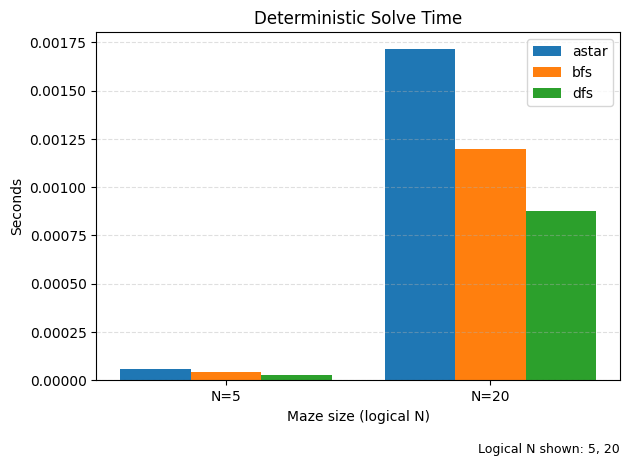

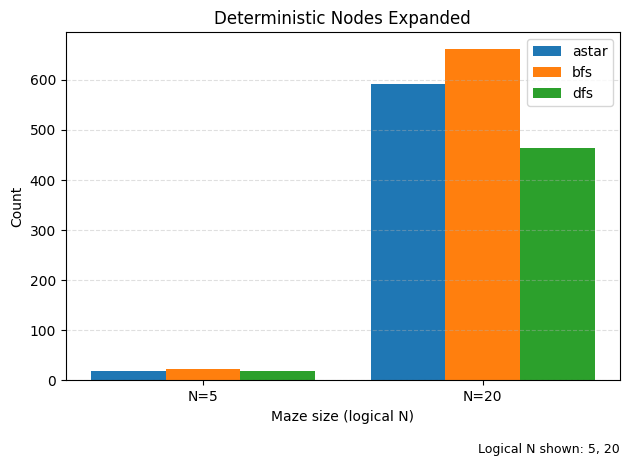

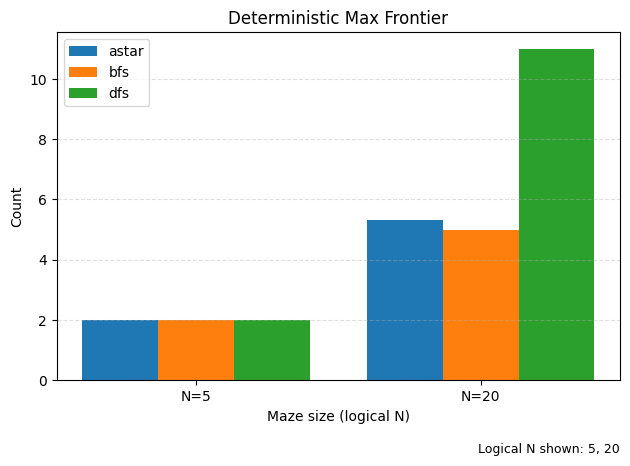

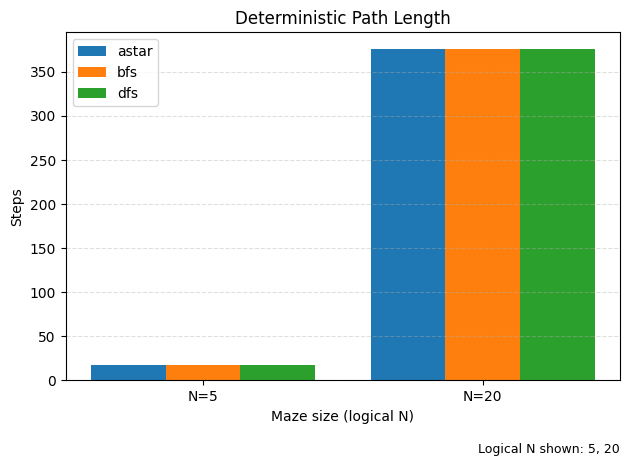

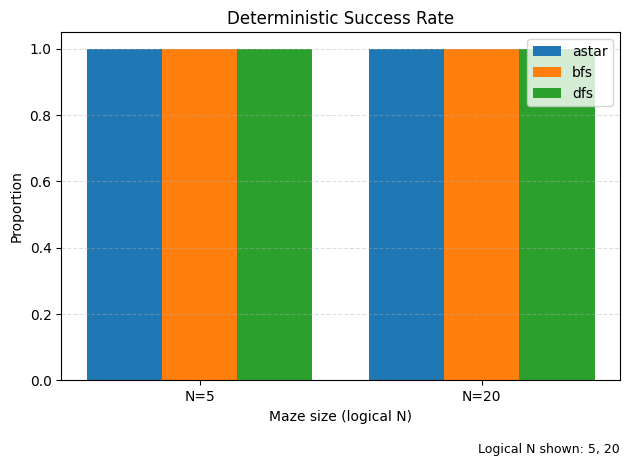

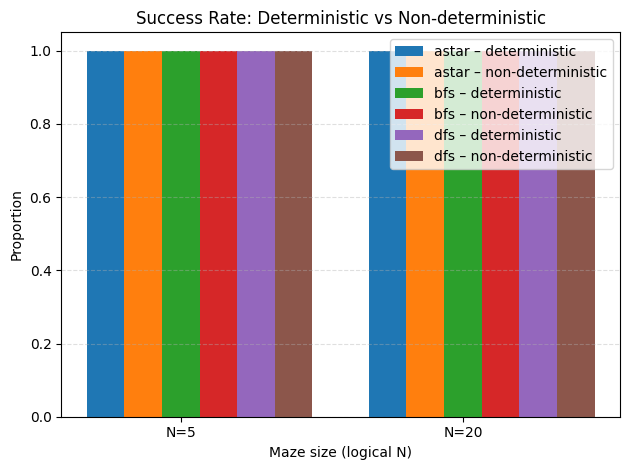

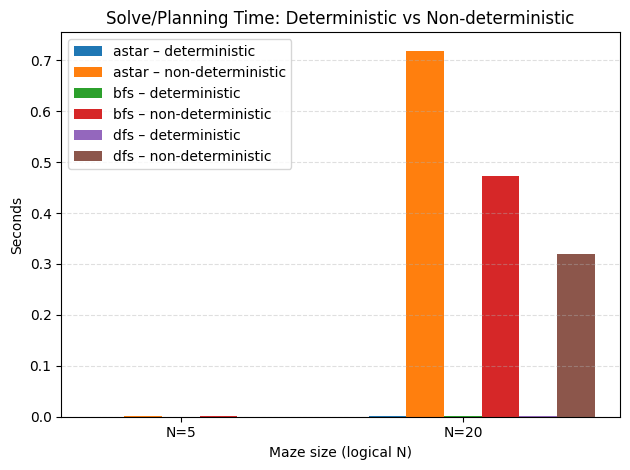

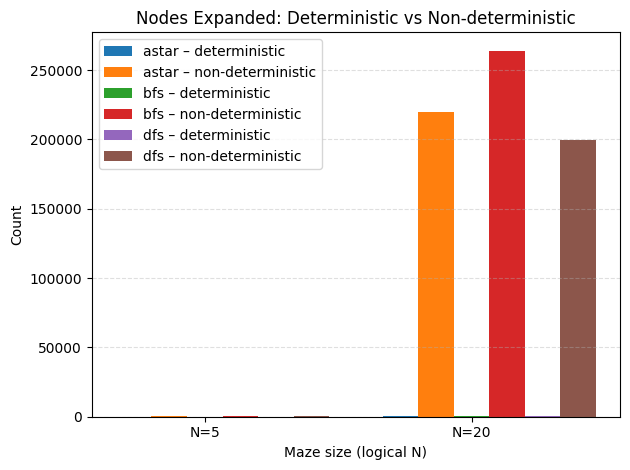

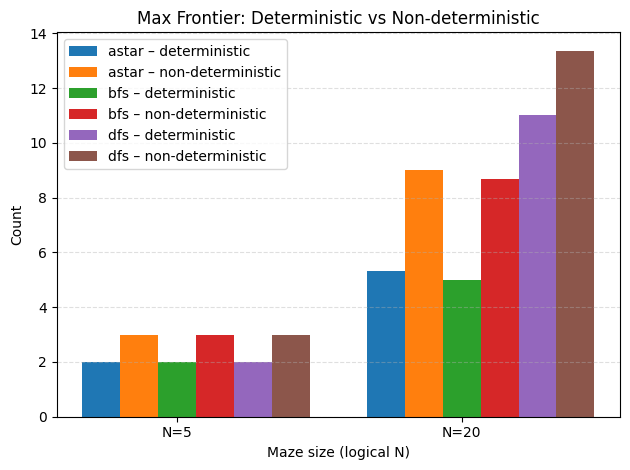

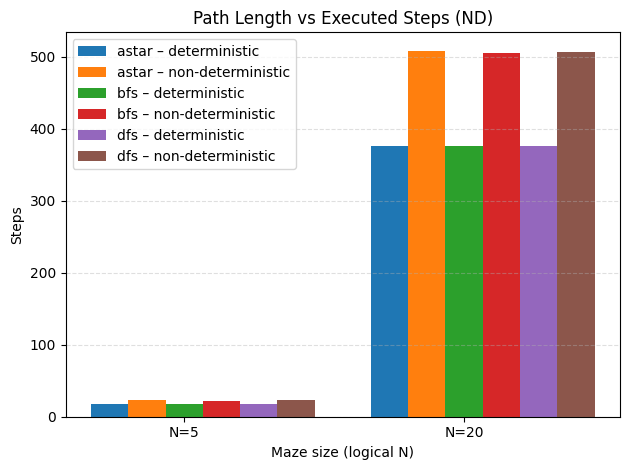

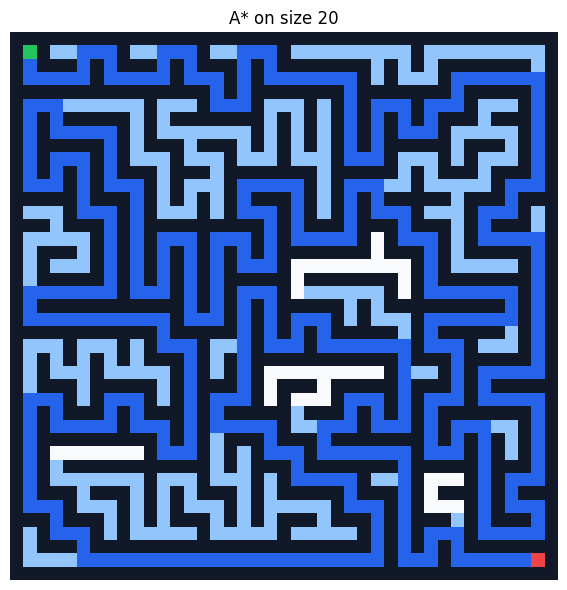

In [ ]:
def demo_one_run(size=7, algorithm='astar', seed=None):
    print(f"Demo run: logical size {size} x {size} (char-grid {(2*size+1)}x{(2*size+1)}), algorithm={algorithm}")
    res = run_single_maze_and_alg(size, size, algorithm, seed=seed)
    grid = res['grid']
    path = res['path']
    overlay = overlay_path(grid, path, res['start'], res['goal'])
    print_grid(overlay)
    print("\nMetrics:")
    print(f"Found: {res['found']}")
    print(f"Time: {res['time']:.6f} s")
    print(f"Nodes Expanded: {res['nodes_expanded']}")
    print(f"Max Frontier Size: {res['max_frontier']}")
    print(f"Path Length (steps): {res['path_length']}")

# main
if __name__ == "__main__":
    demo_one_run(size=20, algorithm='bfs', seed=42)
    print("\n---\n")
    demo_one_run(size=20, algorithm='dfs', seed=42)
    print("\n---\n")
    demo_one_run(size=20, algorithm='astar', seed=42)

    sizes_demo = [5, 20]
    all_results = run_experiments(
        sizes=sizes_demo,
        trials_per_size=3,
        algorithms=['bfs','dfs','astar'],
        max_examples_to_show=1
    )

    # Tidy + plots
    df = experiments_to_dataframe(all_results)
    summary = summarize_results(df)
    print("\nTidy summary (first rows):\n", summary.head(8).to_string(index=False))

    # Deterministic-only overview
    plot_all(summary)

    # Direct deterministic vs non-deterministic comparisons
    plot_det_vs_nd(summary)


    sample = all_results[(20, 'astar')][0]
    render_static(sample['grid'], path=sample.get('path'),
                  start=sample.get('start'), goal=sample.get('goal'),
                  explored=sample.get('visited_order'), title="A* on size 20")

I have checked how this algorithm works in non detesministic enviroment to see the optimization works good or bad. And from the plot you can see every algorithm works bad in non deterministic environment.